In [1]:
import ast
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager
from matplotlib.patches import Rectangle

def extract_genus_name(x):
    try:
        genus_dict = ast.literal_eval(x)
        return genus_dict.get('name', None)
    except:
        return None

label = 'pident_90'
os.chdir('/active-data/analysis_results/chr_pla')
all_data = pd.read_csv('genome_chr-pla_statistics.csv')
all_data['genus_clean'] = all_data['genus'].apply(extract_genus_name)
counts = all_data['genus_clean'].value_counts()
keep_genus = counts[counts >= 400].index.to_list()
print(keep_genus)

font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})

fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()
fontManager.addfont(ifont_path)
ifont_prop = FontProperties(fname=ifont_path)
ifont_name = ifont_prop.get_name()
title_ifont = FontProperties(fname=ifont_path, size=8)

plt.rcParams["font.family"] = [font_name]

['Escherichia', 'Klebsiella', 'Staphylococcus', 'Pseudomonas', 'Bacillus', 'Salmonella', 'Streptococcus', 'Streptomyces', 'Acinetobacter', 'Enterococcus', 'Bordetella', 'Enterobacter', 'Xanthomonas', 'Campylobacter', 'Vibrio', 'Mycobacterium', 'Corynebacterium', 'Burkholderia', 'Listeria', 'Citrobacter', 'Helicobacter']


In [2]:
from collections import defaultdict

def get_ori_data(base_folder, genus_name, label):
    path = f'{base_folder}/statistics_records/{genus_name}/Ori_finder/ori_results.csv'
    df = pd.read_csv(path)
    cats = ['typical plasmid','intermediate replicon','typical chromosome']
    oric = df.groupby(f'category-{label}')['oriC(ORCA)'].agg(['count',lambda x:(x=='Y').sum()])
    oric.columns=['total','y']
    oric['pct'] = oric['y']/oric['total']*100
    oric = [oric.loc[c,'pct'] if c in oric.index else 0 for c in cats]
    vdf = df[df[f'category-{label}']!='typical chromosome']
    oriv = vdf.groupby(f'category-{label}')['oriV(OriV-Finder)'].agg(['count',lambda x:(x=='Y').sum()])
    oriv.columns=['total','y']
    oriv['pct'] = oriv['y']/oriv['total']*100
    oriv = [oriv.loc[c,'pct'] if c in oriv.index else 0 for c in ['typical plasmid','intermediate replicon']]
    return cats, oric, oriv

def plot_oriC(ax, data, cats):
    x = np.arange(len(cats))
    colors = ['#4472C4','#70AD47','#ED7D31']
    ax.bar(x, data, color=colors, width=0.6, alpha=0.8)
    ax.set_title('oriC', font=ifont_prop, pad=3)
    ax.set_ylabel('Replicon\npercentage (%)', labelpad=0)
    ax.tick_params(axis='y', pad=0)
    ax.set_xticks(x)
    ax.set_xticklabels(['Plasmid', 'IR', 'Chromosome'], rotation=45, ha='right', va='top', rotation_mode='anchor')
    ax.set_ylim(0,105)
    ax.set_xlim(-0.5,len(x)-0.5)

def plot_oriV(ax, data):
    x = np.arange(2)
    colors = ['#4472C4','#70AD47']
    ax.bar(x, data, color=colors, width=0.6, alpha=0.8)
    ax.set_title('oriV', font=ifont_prop, pad=3)
    ax.set_xticks(x)
    ax.set_xticklabels(['Plasmid','IR'], rotation=45, ha='right', va='top', rotation_mode='anchor')
    ax.set_ylim(0,105)
    ax.set_xlim(-0.5,len(x)-0.5)

def get_gene_data(base_folder, genus_name):
    def load(f): 
        return ast.literal_eval(open(f'{base_folder}/figure_data/gene_content/{genus_name}/{f}', encoding='utf-8').read().strip())
    t = load('typical plasmid.txt')
    tr= load('intermediate replicon.txt')
    c= load('typical chromosome.txt')
    def pct(d): 
        total=d['all']
        return {k:v/total*100 for k,v in d.items() if k!='all'}
    t,tr,c = pct(t),pct(tr),pct(c)
    genes = sorted(set(t)|set(tr)|set(c),key=lambda g:next((i for i,p in enumerate(['tra','par','sop','rep','dna'])if g.startswith(p)),99))
    def a(d): return [d.get(g,0) for g in genes]
    return genes, a(t),a(tr),a(c)

def plot_gene_content(ax, genes, t, tr, c, ifont_name):
    char_gene_pre = ['tra', 'par', 'sop', 'rep', 'dna']
    gene_priority = {pre: idx for idx, pre in enumerate(char_gene_pre)}

    def sort_key(gene):
        for pre in char_gene_pre:
            if gene.startswith(pre):
                return (gene_priority[pre], gene)
        return (len(char_gene_pre), gene)

    sorted_pairs = sorted(zip(genes, t, tr, c), key=lambda x: sort_key(x[0]))
    genes, t, tr, c = map(list, zip(*sorted_pairs)) if sorted_pairs else ([], [], [], [])
    
    x = np.arange(len(genes))
    w = 0.8/3
    ax.bar(x-w, t, w, label='Typical plasmid', color='#4472C4', alpha=0.8)
    ax.bar(x, tr, w, label='Intermediate replicon', color='#70AD47', alpha=0.8)
    ax.bar(x+w, c, w, label='Typical chromosome', color='#ED7D31', alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(genes, rotation=45, ha='right', va='top', rotation_mode='anchor', fontfamily=ifont_name)
    ax.tick_params(axis='x', pad=0)
    # ax.legend(fontsize=7, loc='upper left')
    ax.set_ylim(0, 105)
    ax.set_xlim(-0.5, len(genes) - 0.5)

    color_map = {
        'rep': '#1B9E77',
        'tra': '#A6761D',
        'par': '#7570B3',
        'sop': '#7570B3',
        'dna': '#1B9E77',
    }
    gene_prefixes = ['rep', 'tra', 'par', 'sop', 'dna']
    for tick_label in ax.get_xticklabels():
        gene = tick_label.get_text()
        for pre in gene_prefixes:
            if gene.startswith(pre):
                tick_label.set_color(color_map[pre])
                break

    gene_indices = defaultdict(list)
    for idx, gene in enumerate(genes):
        for prefix in gene_prefixes:
            if gene.startswith(prefix):
                gene_indices[prefix].append(idx)
                break

    groups = [
        ('tra', '#A6761D', 'Plasmid transfer genes'),
        ('par_sop', '#7570B3', 'Partition genes'),
        ('rep_dna', '#1B9E77', 'Replication genes')
    ]

    y_top = ax.get_ylim()[1]
    rect_height = 10
    for prefix_group, color, label in groups:
        if prefix_group == 'tra':
            indices = gene_indices.get('tra', [])
        elif prefix_group == 'par_sop':
            indices = gene_indices.get('par', []) + gene_indices.get('sop', [])
        else:
            indices = gene_indices.get('rep', []) + gene_indices.get('dna', [])
        
        if not indices:
            continue
        left, right = min(indices) - 0.5, max(indices) + 0.5
        ax.add_patch(plt.Rectangle((left, y_top + 5), right-left, rect_height, color=color, alpha=0.7, lw=0, clip_on=False))
        # ax.text((left+right)/2, y_top + 1 + rect_height, label, ha='center', va='bottom', fontsize=7, color=color)

    major_groups = [{'tra'}, {'par', 'sop'}, {'rep', 'dna'}]
    if len(genes) == 0:
        return
    
    prev_prefix = None
    prev_major_group = None
    for idx, gene in enumerate(genes):
        curr_prefix = None
        for p in gene_prefixes:
            if gene.startswith(p):
                curr_prefix = p
                break
        if not curr_prefix:
            continue

        curr_major_group = None
        for g in major_groups:
            if curr_prefix in g:
                curr_major_group = g
                break

        if idx == 0:
            prev_prefix = curr_prefix
            prev_major_group = curr_major_group
            continue

        x_line = idx - 0.5
        if curr_major_group != prev_major_group:
            ax.axvline(x=x_line, color='#707070', lw=1.0, linestyle='-', zorder=0)
        elif curr_prefix != prev_prefix:
            ax.axvline(x=x_line, color='#AAAAAA', lw=0.8, linestyle='--', zorder=0)
        else:
            ax.axvline(x=x_line, color='#DDDDDD', lw=0.5, linestyle=':', zorder=0)

        prev_prefix = curr_prefix
        prev_major_group = curr_major_group

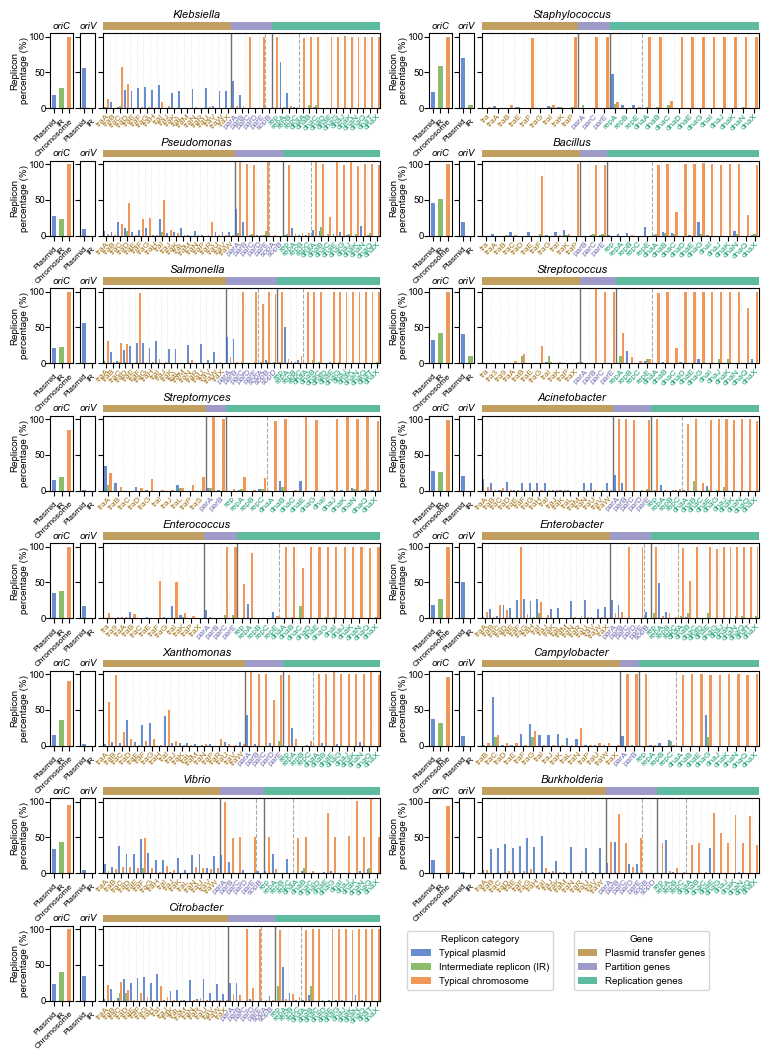

In [3]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(7.5, 7.5))

base_folder = f'/active-data/analysis_results/chr_pla/genus'
label = 'pident_90'
i = 0
gap = 0.04
for genus_name in keep_genus:
    folder = f'{base_folder}/statistics_records/{genus_name}'
    fraction_data = pd.read_csv(f'{folder}/replicon-plasmid_fraction-self_bitscore_statistics.csv')
    if len(fraction_data[fraction_data[f'category-{label}']=='intermediate replicon']) < 5 or genus_name=='Escherichia':
        continue
    i += 1
    rep_y_site = 1 - 0.13*int((i + 1)/2) - gap*int((i - 1)/2)
    fig.text(0.25 + 0.5*((i + 1)%2), rep_y_site+0.12, genus_name, ha='center', fontproperties=title_ifont)
    ax_oriC = fig.add_axes([0.055 + 0.505*((i + 1)%2), rep_y_site, 0.03, 0.1])
    ax_oriV = fig.add_axes([0.095 + 0.505*((i + 1)%2), rep_y_site, 0.02, 0.1])
    ax_oriV.set_yticklabels([])
    ax_gene_content = fig.add_axes([0.125 + 0.505*((i + 1)%2), rep_y_site, 0.5-0.13, 0.1])
    ax_gene_content.set_yticklabels([])
    cats, oriC_data, oriV_data = get_ori_data(base_folder, genus_name, label)
    plot_oriC(ax_oriC, oriC_data, cats)
    plot_oriV(ax_oriV, oriV_data)
    genes, t_data, tr_data, c_data = get_gene_data(base_folder, genus_name)
    plot_gene_content(ax_gene_content, genes, t_data, tr_data, c_data, ifont_name)

replicon_elements = [Patch(facecolor='#4472C4',label='Typical plasmid', alpha=0.8), 
                     Patch(facecolor='#70AD47',label='Intermediate replicon (IR)', alpha=0.8), 
                     Patch(facecolor='#ED7D31',label='Typical chromosome', alpha=0.8)]
leg1 = ax_gene_content.legend(handles=replicon_elements, loc='upper left',bbox_to_anchor=(1.08,0.99),fontsize=7,title='Replicon category',ncol=1)
ax_gene_content.add_artist(leg1)
gene_elements = [Patch(facecolor='#A6761D',label='Plasmid transfer genes', alpha=0.7), 
                 Patch(facecolor='#7570B3',label='Partition genes', alpha=0.7), 
                 Patch(facecolor='#1B9E77',label='Replication genes', alpha=0.7)]
ax_gene_content.legend(handles=gene_elements, loc='upper left',bbox_to_anchor=(1.68,0.99),fontsize=7,title='Gene',ncol=1)

rect = plt.Rectangle((0, 0), 1, 1, transform=fig.transFigure, facecolor='none', edgecolor='black', linewidth=2)
# fig.patches.append(rect)

figure_fold = f'{base_folder}/figures'
os.chdir(figure_fold)
plt.savefig(f"S_all_genera_ori_and_gene(more_than_5).svg", bbox_inches="tight", transparent=True)
plt.savefig(f"S_all_genera_ori_and_gene(more_than_5).png", dpi=1000, bbox_inches="tight", transparent=True)

plt.show()